# Análisis Exploratorio de Datos — Riesgo Crediticio

**Proyecto:** Modelo Predictivo de Riesgo Crediticio
**Notebook:** `comprension_eda.ipynb`
**Fase:** 2 — Análisis Exploratorio de Datos
**Versión:** V1.0.3
**Rama:** developer
**Autor:** Harrison

---

## Contexto de negocio

Empresa financiera que otorga créditos a personas naturales. El área de Datos y Analítica necesita un modelo predictivo supervisado que **anticipe si un cliente nuevo pagará su crédito a tiempo** a partir de información histórica de créditos previamente otorgados.

La variable objetivo es `Pago_atiempo`:
- `1` → el cliente pagó a tiempo
- `0` → el cliente NO pagó a tiempo (cliente de interés para el modelo)

El dataset presenta un **fuerte desbalance**: aproximadamente 95% de los clientes pagan a tiempo y solo 5% no lo hacen. Esto condiciona toda la estrategia de modelado posterior.

---

## Objetivo del notebook

Diagnosticar el dataset `Base_de_datos.csv` para producir **conocimiento accionable** que alimente las fases siguientes del proyecto:

1. **Comprender la estructura** de los datos: tamaño, tipos, calidad, nulos, duplicados.
2. **Caracterizar cada variable** de forma univariable (distribución, outliers, valores anómalos).
3. **Identificar relaciones** entre cada feature y la variable objetivo (bivariable).
4. **Detectar multicolinealidad** y redundancias entre features (multivariable).
5. **Documentar decisiones** de limpieza, transformación y eliminación de columnas que se ejecutarán en `ft_engineering.py`.

---

## Alcance y límites

Este notebook **solo diagnostica**. No modifica el dataset original, no imputa nulos, no elimina columnas, no transforma variables. Todas esas acciones quedan documentadas como decisiones explícitas en la sección final y se ejecutan en la Fase 3 (Feature Engineering).

---

## Estructura del notebook

| Sección | Contenido |
|---|---|
| 0 | Setup: imports, configuración y carga de datos |
| 1 | Visión global: shape, tipos, nulos, duplicados |
| 2 | Análisis univariable del target |
| 3 | Univariable de variables numéricas |
| 4 | Univariable de variables categóricas |
| 5 | Bivariable: cada feature vs `Pago_atiempo` |
| 6 | Multivariable: correlaciones y redundancias |
| 7 | Conclusiones y decisiones para Feature Engineering |

# 0 Librerias

In [1]:
# =============================================================================
# SECCIÓN 0 - SETUP
# Notebook de Análisis Exploratorio de Datos (EDA)
# Proyecto: Modelo Predictivo de Riesgo Crediticio
# Variable objetivo: Pago_atiempo (1 = paga a tiempo, 0 = no paga a tiempo)
# =============================================================================

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración global de visualización
sns.set_theme(style="whitegrid")        # Fondo blanco con grilla, lectura cómoda
plt.rcParams["figure.figsize"] = (10, 6) # Tamaño por defecto de figuras
plt.rcParams["axes.titlesize"] = 12      # Tamaño de títulos consistente
pd.set_option("display.max_columns", None)  # Mostrar todas las columnas en describe/head
pd.set_option("display.float_format", "{:,.2f}".format)  # Floats legibles con separador de miles

In [2]:
# =============================================================================
# Carga del dataset
# Ruta: el CSV vive en la raíz del proyecto, el notebook en src/
# Por eso usamos '../Base_de_datos.csv' (subir un nivel)
# =============================================================================

# Leemos el CSV y convertimos fecha_prestamo a datetime desde la lectura
df = pd.read_csv(
    "../Base_de_datos.csv",
    parse_dates=["fecha_prestamo"]  # Evita conversión manual posterior
)

# Confirmación rápida de carga
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head(3)

Filas: 10,763
Columnas: 23


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,"3,692,160.00",10,42,Independiente,8000000,2500000,341296,88.77,695.00,10,5,0.00,"51,258.00","51,258.00",0.00,5,0,0,"908,526.00",Estable,1
1,4,2025-04-22 09:47:35,"840,000.00",6,60,Empleado,3000000,2000000,124876,95.23,789.00,3,1,0.00,"8,673.00","8,673.00",0.00,0,0,2,"939,017.00",Creciente,1
2,9,2026-01-08 12:22:40,"5,974,028.40",10,36,Independiente,4036000,829000,529554,47.61,740.00,4,5,0.00,"18,702.00","18,702.00",0.00,3,0,0,NaN,NaN,0


In [3]:
# =============================================================================
# Estructura del DataFrame: tipos de datos y memoria
# df.info() es la radiografía rápida del dataset
# =============================================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[us]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  str           
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvigentes     

## 1. Visión global del dataset

Antes de analizar variables individualmente, evaluamos la calidad estructural del dataset: tamaño, integridad de los datos (nulos), y presencia de registros duplicados.

Esta sección responde tres preguntas:
1. ¿Cuántos registros y variables tenemos?
2. ¿Qué tan completo está el dataset? ¿Qué columnas tienen nulos y en qué proporción?
3. ¿Existen filas duplicadas que puedan sesgar el análisis?

In [4]:
# =============================================================================
# Análisis de nulos
# Calculamos cantidad y porcentaje de nulos por columna
# Solo mostramos las columnas que TIENEN al menos un nulo
# =============================================================================

# Conteo de nulos por columna
nulos_conteo = df.isnull().sum()

# Porcentaje de nulos sobre el total de filas
nulos_pct = (df.isnull().sum() / len(df) * 100).round(2)

# Armamos una tabla resumen ordenada de mayor a menor
resumen_nulos = pd.DataFrame({
    "nulos": nulos_conteo,
    "porcentaje": nulos_pct
})

# Filtramos solo columnas con nulos y ordenamos descendente
resumen_nulos = resumen_nulos[resumen_nulos["nulos"] > 0].sort_values(
    "nulos", ascending=False
)

resumen_nulos

,nulos,porcentaje
tendencia_ingresos,2932,27.24
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06


Críticos (27%): tendencia_ingresos y promedio_ingresos_datacredito — vienen del mismo sistema externo (DataCrédito). Los 2 registros de diferencia (2932 vs 2930) sugieren que hay 2 filas donde hay ingreso pero no tendencia, probablemente error de captura puntual.

In [5]:
# =============================================================================
# ¿Los 156 nulos de saldo_mora y saldo_total son los MISMOS registros?
# Si lo son, probablemente sean créditos muy nuevos sin historial calculado
# =============================================================================

# Filas donde saldo_mora es nulo
filas_nulo_mora = df["saldo_mora"].isnull()

# Filas donde saldo_total es nulo  
filas_nulo_total = df["saldo_total"].isnull()

# Coincidencia exacta entre ambos conjuntos
coincidencia = (filas_nulo_mora == filas_nulo_total).all()

print(f"¿Los nulos de saldo_mora y saldo_total son los mismos registros? {coincidencia}")
print(f"Cantidad de nulos en saldo_mora: {filas_nulo_mora.sum()}")
print(f"Cantidad de nulos en saldo_total: {filas_nulo_total.sum()}")

¿Los nulos de saldo_mora y saldo_total son los mismos registros? True
Cantidad de nulos en saldo_mora: 156
Cantidad de nulos en saldo_total: 156


156 registros son créditos "vacíos" donde ningún saldo se calculó. 

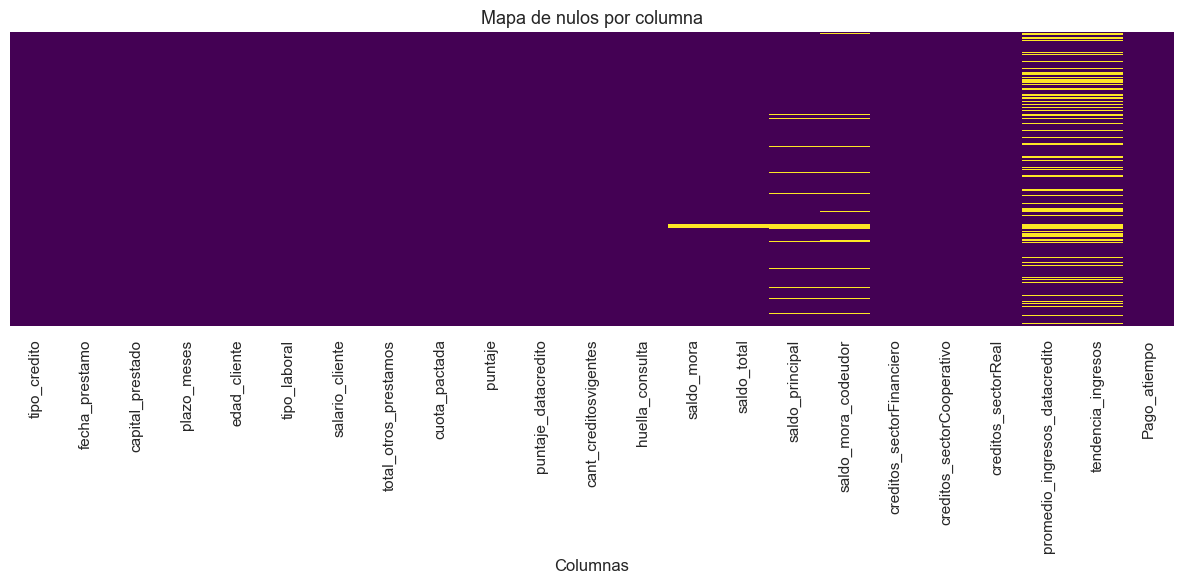

In [6]:
# =============================================================================
# Visualización de nulos: heatmap
# Cada fila del dataset es una línea horizontal; cada columna es una columna
# Las celdas amarillas indican valores nulos
# Sirve para detectar patrones de "nulos juntos" (registros incompletos)
# =============================================================================

plt.figure(figsize=(12, 6))
sns.heatmap(
    df.isnull(),
    cbar=False,            # Sin barra de color, solo nos importa nulo/no-nulo
    yticklabels=False,     # 10k filas no se pueden etiquetar, las ocultamos
    cmap="viridis"         # Amarillo = nulo, morado = no nulo
)
plt.title("Mapa de nulos por columna", fontsize=13)
plt.xlabel("Columnas")
plt.tight_layout()
plt.show()

* Algunos clientes específicos simplemente no tienen registro en DataCrédito — clientes nuevos en el sistema financiero, informales, o que nunca han tenido crédito antes.
* Son exactamente los mismos registros sin DataCrédito. No es ruido aleatorio, es un patrón coherente con la fuente externa.
*  "no tener DataCrédito" puede ser en sí mismo una señal predictiva. Un cliente sin historial crediticio es un perfil de riesgo distinto al que sí lo tiene    

## Decisiones de nulos tomadas

| Columna | % Nulos | Decisión |
|---|---|---|
| `promedio_ingresos_datacredito` | 27% | Crear variable indicadora `tiene_datacredito` (0/1) **antes** de imputar. Luego imputar con mediana. |
| `tendencia_ingresos` | 27% | Los ~58 valores contaminados → convertir a NaN primero. Luego imputar con moda o crear categoría `"Sin_info"`. La decisión final se toma en Fase 3. |
| `saldo_mora_codeudor` | 5.5% | **Eliminar columna completa** — 100% de no-nulos son cero, cero varianza. |
| `saldo_principal` | 3.7% | Imputar con mediana (imputación simple, <5%). |
| `saldo_mora` | 1.45% | Imputar con **0** — confirmado que son los mismos 156 registros sin ningún saldo calculado (créditos muy nuevos). |
| `saldo_total` | 1.45% | Imputar con **0** — mismos 156 registros que `saldo_mora`. |
| `puntaje_datacredito` | 0.06% | Imputar con mediana (6 registros, despreciable). |



In [7]:
# =============================================================================
# Detección de filas duplicadas
# Un duplicado es una fila idéntica en TODAS las 23 columnas
# Si existen, hay que decidir si eliminarlos (sesgo) o si son legítimos
# =============================================================================

n_duplicados = df.duplicated().sum()
print(f"Filas duplicadas exactas: {n_duplicados}")
print(f"Porcentaje: {n_duplicados / len(df) * 100:.2f}%")

Filas duplicadas exactas: 0
Porcentaje: 0.00%


## 2. Análisis univariable del target

Antes de analizar cualquier feature, caracterizamos la variable objetivo `Pago_atiempo`.
La distribución del target condiciona toda la estrategia de modelado posterior:
qué métrica optimizar, cómo hacer el split de datos, qué algoritmos considerar.

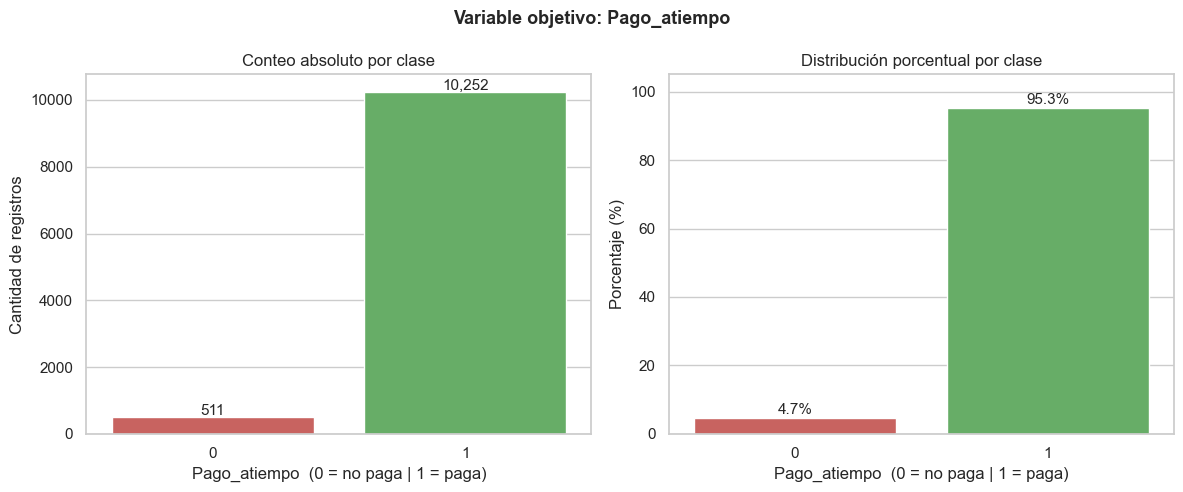


Resumen del target:
Pago_atiempo
Paga (1)       10252
No paga (0)      511
Name: count, dtype: int64


In [8]:
# =============================================================================
# Distribución del target: Pago_atiempo
# Visualizamos conteos absolutos y porcentajes para dimensionar el desbalance
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Ordenamos 0 → 1 para que rojo=no paga, verde=paga
conteos = df["Pago_atiempo"].value_counts().sort_index()
pct = df["Pago_atiempo"].value_counts(normalize=True).sort_index() * 100

# Colores explícitos por posición (evita el warning de palette sin hue)
colores = ["#d9534f", "#5cb85c"]  # Rojo = no paga (0), verde = paga (1)

# --- Gráfico izquierdo: conteos absolutos ---
sns.barplot(
    x=conteos.index,
    y=conteos.values,
    hue=conteos.index,        # hue requerido desde seaborn 0.13+
    palette=colores,
    legend=False,             # ocultamos la leyenda redundante
    ax=axes[0]
)
axes[0].set_title("Conteo absoluto por clase")
axes[0].set_xlabel("Pago_atiempo  (0 = no paga | 1 = paga)")
axes[0].set_ylabel("Cantidad de registros")

for i, v in enumerate(conteos.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontsize=11)

# --- Gráfico derecho: porcentajes ---
sns.barplot(
    x=pct.index,
    y=pct.values,
    hue=pct.index,            # hue requerido desde seaborn 0.13+
    palette=colores,
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Distribución porcentual por clase")
axes[1].set_xlabel("Pago_atiempo  (0 = no paga | 1 = paga)")
axes[1].set_ylabel("Porcentaje (%)")
axes[1].set_ylim(0, 105)

for i, v in enumerate(pct.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=11)

plt.suptitle("Variable objetivo: Pago_atiempo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nResumen del target:")
print(df["Pago_atiempo"].value_counts().rename({0: "No paga (0)", 1: "Paga (1)"}))

### Conclusión: desbalance y su impacto en la estrategia

El dataset presenta un **fuerte desbalance de clases**:
- **95.3% paga a tiempo** (clase 1): 10,252 registros
- **4.7% no paga** (clase 0): 511 registros — estos son los clientes de interés

#### Implicaciones directas para el modelado

| Decisión | Consecuencia del desbalance |
|---|---|
| **Métrica principal** | Accuracy es inútil: un modelo que prediga siempre "1" acierta 95.3% sin aprender nada. Usaremos ROC-AUC y F1 de la clase 0. |
| **Validación** | El split train/test debe usar `stratify=y` para garantizar que ambas particiones mantengan el mismo 5% de morosos. |
| **Algoritmos** | Preferir modelos con parámetro `class_weight="balanced"` o técnicas de resampling (SMOTE) en Fase 4. |
| **Umbral de decisión** | El umbral por defecto (0.5) probablemente no sea óptimo. Se evaluará ajustar en Fase 4. |

**El objetivo real del modelo no es "predecir bien en general" sino
"detectar el mayor número posible de los 511 clientes morosos
sin generar demasiadas falsas alarmas."**

## 3. Análisis univariable — Variables numéricas

Analizamos la distribución individual de cada variable numérica:
forma (simétrica, sesgada), rango, concentración y presencia de outliers.

El criterio de descarte en cada caso es de negocio:
¿este outlier es un error de captura o un cliente real atípico?

In [9]:
# =============================================================================
# Estadísticos descriptivos de todas las variables numéricas
# Excluimos la variable objetivo y fecha_prestamo (no son numéricas de análisis)
# =============================================================================

# Seleccionamos columnas numéricas excluyendo el target
cols_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cols_numericas.remove("Pago_atiempo")  # El target no es una feature

df[cols_numericas].describe().T  # Transponemos para leer mejor con 19 columnas

,count,mean,std,min,25%,50%,75%,max
tipo_credito,"10,763.00",5.41,2.34,4.00,4.00,4.00,9.00,68.00
capital_prestado,"10,763.00","2,434,315.00","1,909,642.76","360,000.00","1,224,831.00","1,921,920.00","3,084,840.00","41,444,152.80"
plazo_meses,"10,763.00",10.58,6.63,2.00,6.00,10.00,12.00,90.00
edad_cliente,"10,763.00",43.95,15.06,19.00,33.00,42.00,53.00,123.00
salario_cliente,"10,763.00","17,216,431.46","355,476,717.60",0.00,"2,000,000.00","3,000,000.00","4,875,808.00","22,000,000,000.00"
total_otros_prestamos,"10,763.00","6,238,869.65","118,418,316.94",0.00,"500,000.00","1,000,000.00","2,000,000.00","6,787,675,263.00"
cuota_pactada,"10,763.00","243,617.41","210,493.69","23,944.00","121,041.50","182,863.00","287,833.50","3,816,752.00"
puntaje,"10,763.00",91.17,16.47,-38.01,95.23,95.23,95.23,95.23
puntaje_datacredito,"10,757.00",780.79,104.88,-7.00,757.00,791.00,825.00,999.00
cant_creditosvigentes,"10,763.00",5.73,3.98,0.00,3.00,5.00,8.00,62.00


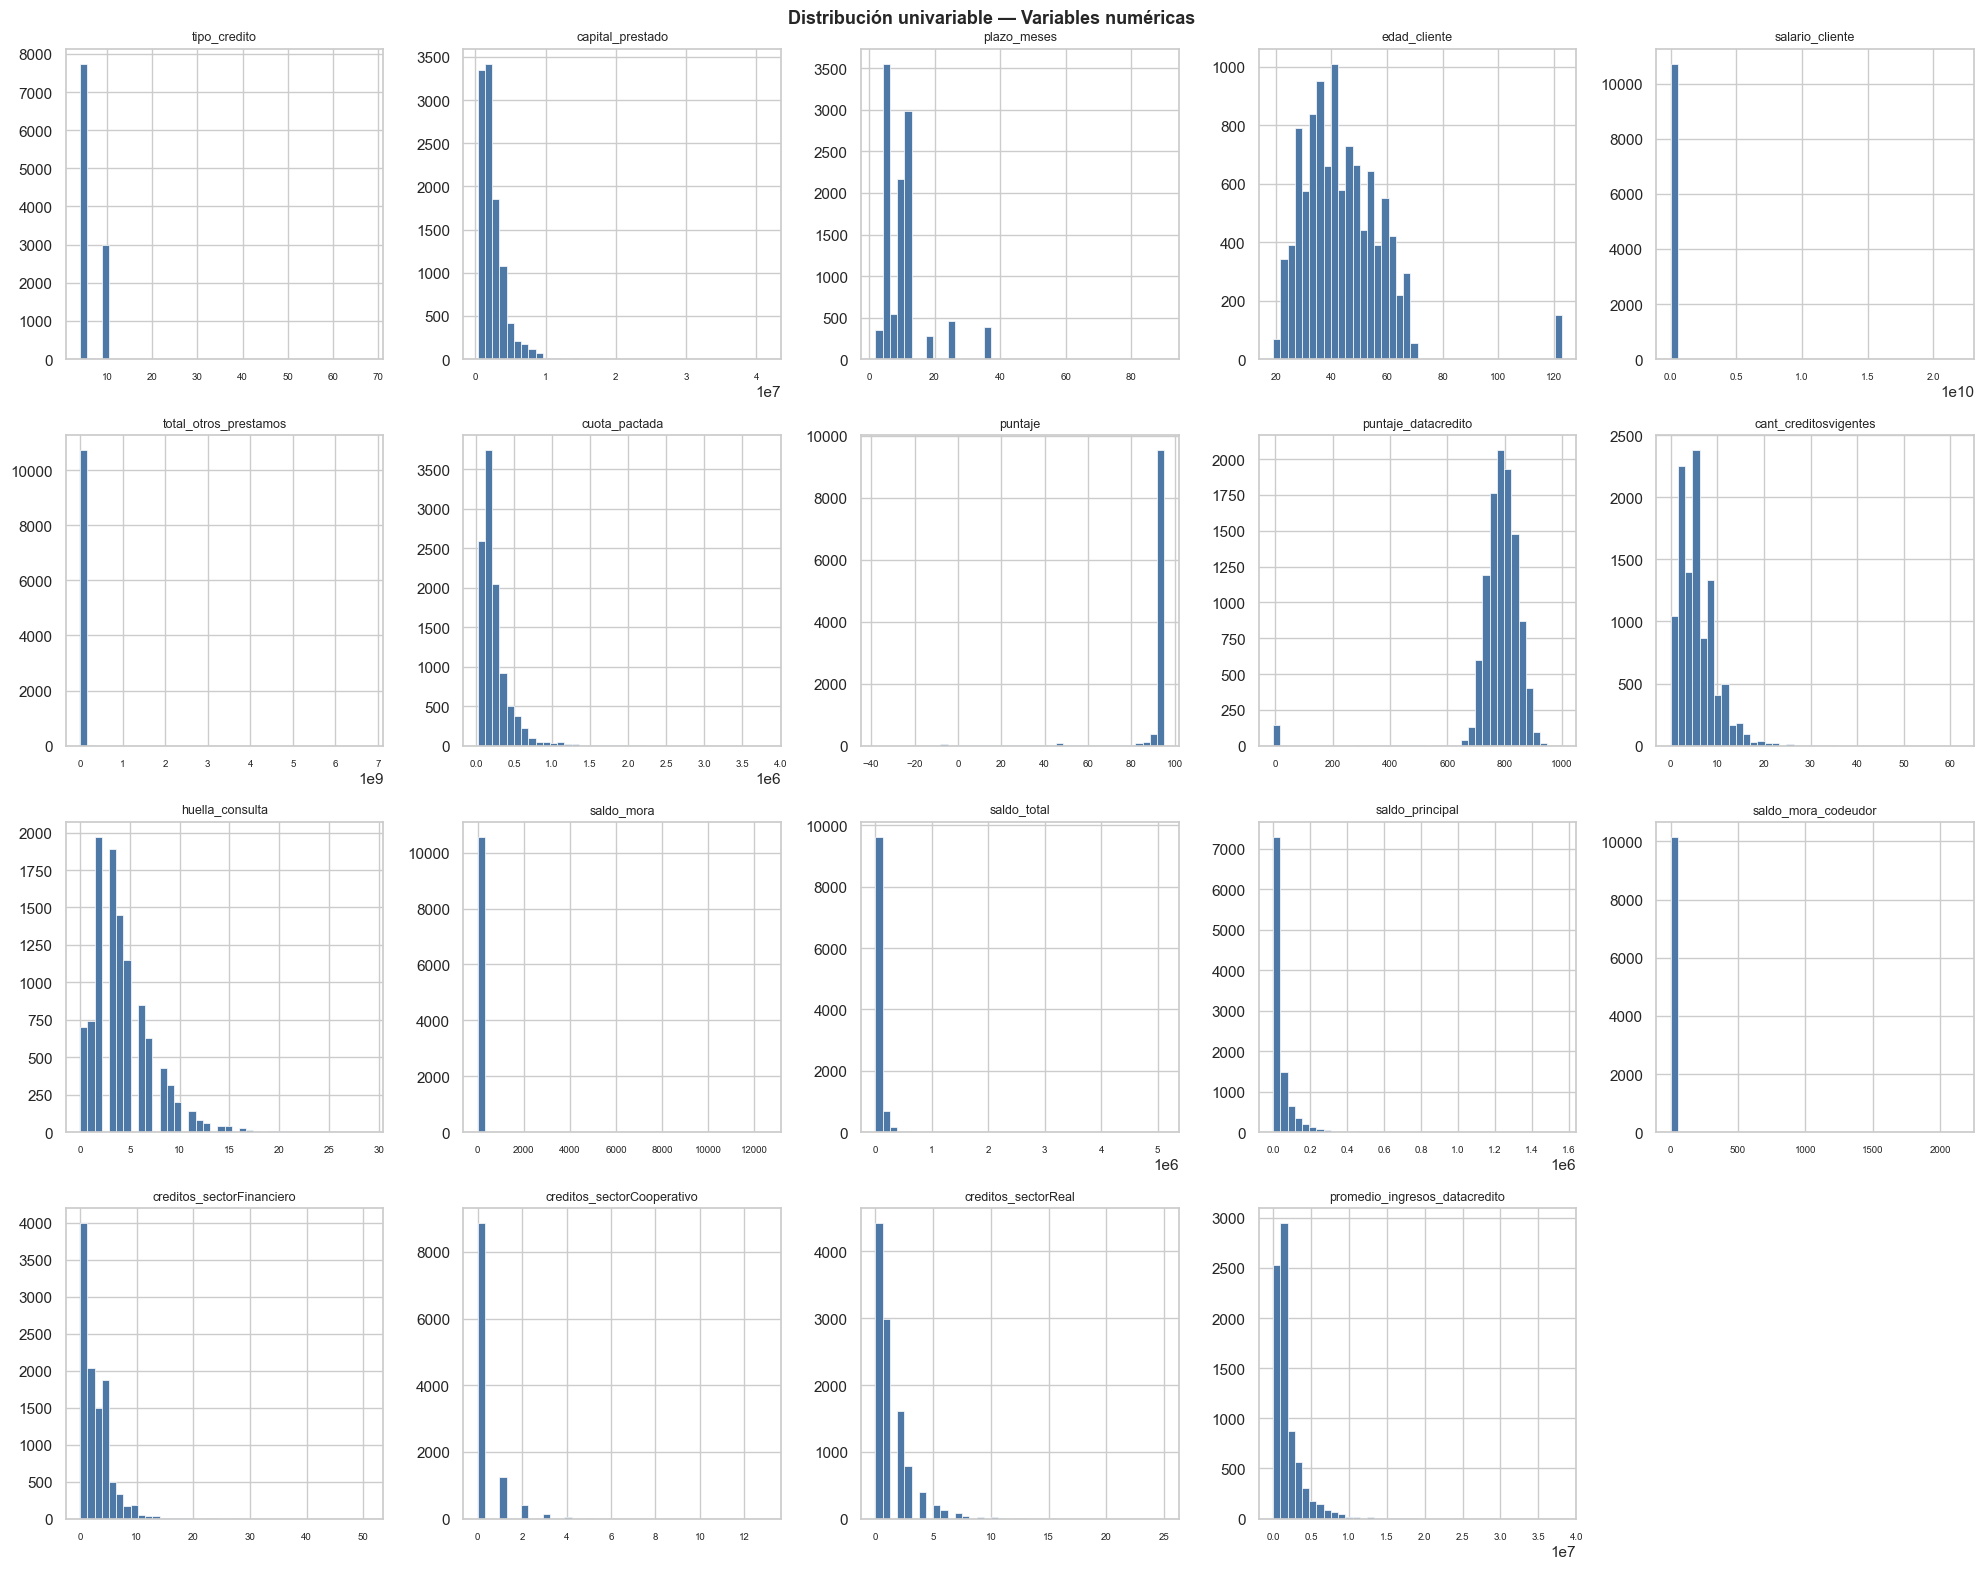

In [10]:
# =============================================================================
# Histogramas de todas las variables numéricas
# Detectamos forma de distribución y outliers visualmente
# =============================================================================

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()  # Convertimos la grilla 4x5 en lista de 20 ejes

for i, col in enumerate(cols_numericas):
    axes[i].hist(
        df[col].dropna(),   # Ignoramos nulos para el histograma
        bins=40,
        color="#4e79a7",
        edgecolor="white",
        linewidth=0.5
    )
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", labelsize=7)

# Ocultamos los ejes sobrantes (tenemos 19 variables, la grilla tiene 20)
for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución univariable — Variables numéricas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

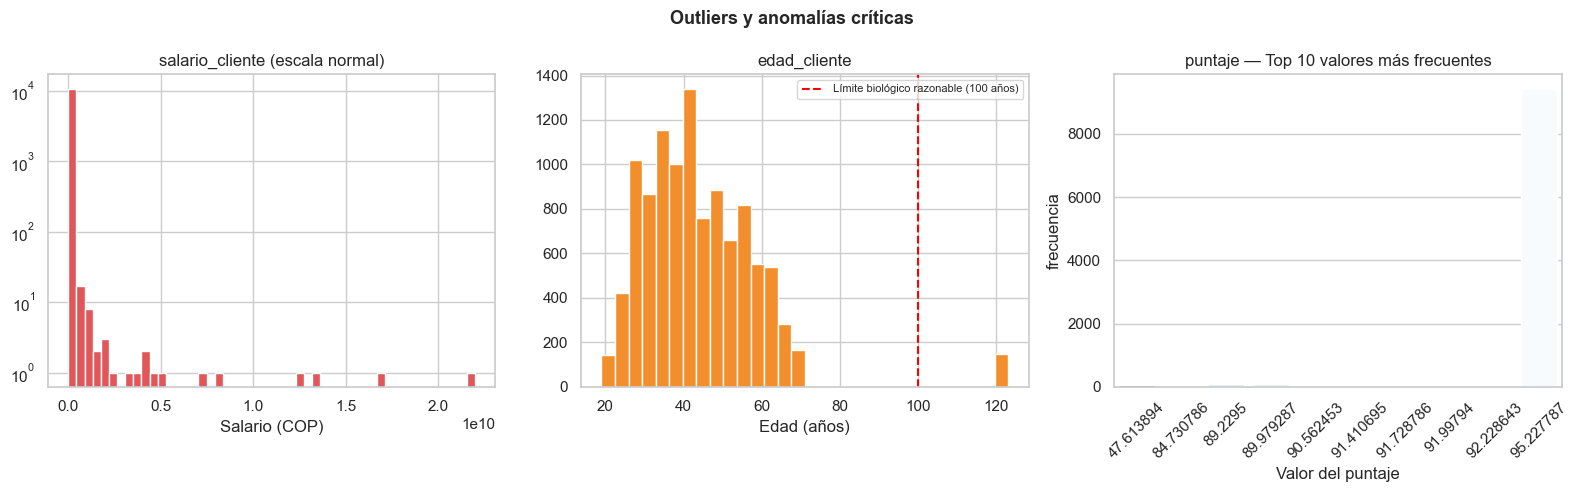

=== salario_cliente > 1,000,000,000 (más de mil millones) ===
Cantidad: 22 registros

=== edad_cliente >= 100 ===
Cantidad: 150 registros

=== puntaje == 95.227787 ===
Cantidad: 9407 registros
Porcentaje: 87.4%


In [11]:
# =============================================================================
# Análisis puntual de las 3 variables con outliers más críticos
# Usamos escala logarítmica donde aplica para ver la distribución real
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- salario_cliente en escala log ---
axes[0].hist(
    df["salario_cliente"].dropna(),
    bins=50,
    color="#e15759",
    edgecolor="white"
)
axes[0].set_title("salario_cliente (escala normal)")
axes[0].set_xlabel("Salario (COP)")
axes[0].set_yscale("log")  # Eje Y log para ver la cola

# --- edad_cliente ---
axes[1].hist(
    df["edad_cliente"].dropna(),
    bins=30,
    color="#f28e2b",
    edgecolor="white"
)
axes[1].set_title("edad_cliente")
axes[1].set_xlabel("Edad (años)")
axes[1].axvline(x=100, color="red", linestyle="--", linewidth=1.5,
                label="Límite biológico razonable (100 años)")
axes[1].legend(fontsize=8)

# --- puntaje: revelar la degeneración ---
top_puntajes = df["puntaje"].value_counts().head(10).reset_index()
top_puntajes.columns = ["puntaje", "frecuencia"]
sns.barplot(
    data=top_puntajes,
    x="puntaje",
    y="frecuencia",
    hue="puntaje",
    palette="Blues_r",
    legend=False,
    ax=axes[2]
)
axes[2].set_title("puntaje — Top 10 valores más frecuentes")
axes[2].set_xlabel("Valor del puntaje")
axes[2].tick_params(axis="x", rotation=45)

plt.suptitle("Outliers y anomalías críticas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Tabla resumen de los casos extremos
print("=== salario_cliente > 1,000,000,000 (más de mil millones) ===")
print(f"Cantidad: {(df['salario_cliente'] > 1_000_000_000).sum()} registros")

print("\n=== edad_cliente >= 100 ===")
print(f"Cantidad: {(df['edad_cliente'] >= 100).sum()} registros")

print("\n=== puntaje == 95.227787 ===")
valor_puntaje = 95.227787
print(f"Cantidad: {(df['puntaje'] == valor_puntaje).sum()} registros")
print(f"Porcentaje: {(df['puntaje'] == valor_puntaje).sum() / len(df) * 100:.1f}%")

In [12]:
# =============================================================================
# Detección de outliers mediante método IQR (Interquartile Range)
# Más robusto que z-score para distribuciones sesgadas (datos financieros)
# Outlier: valor por debajo de Q1 - 1.5*IQR o por encima de Q3 + 1.5*IQR
# =============================================================================

def detectar_outliers_iqr(df: pd.DataFrame, columnas: list) -> pd.DataFrame:
    """
    Calcula límites IQR y cuenta outliers por columna.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con los datos originales.
    columnas : list
        Lista de nombres de columnas numéricas a analizar.

    Returns
    -------
    pd.DataFrame
        Tabla resumen con límites, conteos y porcentajes de outliers.
    """
    resultados = []

    for col in columnas:
        serie = df[col].dropna()

        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1

        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        # Contamos registros fuera de los límites
        n_outliers_sup = (serie > limite_superior).sum()
        n_outliers_inf = (serie < limite_inferior).sum()
        n_outliers_total = n_outliers_sup + n_outliers_inf

        resultados.append({
            "columna": col,
            "Q1": round(q1, 2),
            "Q3": round(q3, 2),
            "IQR": round(iqr, 2),
            "limite_inferior": round(limite_inferior, 2),
            "limite_superior": round(limite_superior, 2),
            "outliers_inf": n_outliers_inf,   # Por debajo del límite
            "outliers_sup": n_outliers_sup,   # Por encima del límite
            "outliers_total": n_outliers_total,
            "pct_outliers": round(n_outliers_total / len(serie) * 100, 2)
        })

    return pd.DataFrame(resultados).set_index("columna").sort_values(
        "pct_outliers", ascending=False
    )

# Ejecutamos sobre todas las numéricas excepto el target
resumen_outliers = detectar_outliers_iqr(df, cols_numericas)
resumen_outliers

,Q1,Q3,IQR,limite_inferior,limite_superior,outliers_inf,outliers_sup,outliers_total,pct_outliers
columna,,,,,,,,,
creditos_sectorCooperativo,0.00,0.00,0.00,0.00,0.00,0,1895,1895,17.61
puntaje,95.23,95.23,0.00,95.23,95.23,1356,0,1356,12.60
promedio_ingresos_datacredito,"925,157.00","2,231,859.00","1,306,702.00","-1,034,896.00","4,191,912.00",0,784,784,10.01
saldo_principal,"2,690.00","47,632.25","44,942.25","-64,723.38","115,045.62",0,951,951,9.18
saldo_total,"2,898.00","52,982.00","50,084.00","-72,228.00","128,108.00",0,970,970,9.14
plazo_meses,6.00,12.00,6.00,-3.00,21.00,0,869,869,8.07
cuota_pactada,"121,041.50","287,833.50","166,792.00","-129,146.50","538,021.50",0,765,765,7.11
salario_cliente,"2,000,000.00","4,875,808.00","2,875,808.00","-2,313,712.00","9,189,520.00",0,718,718,6.67
total_otros_prestamos,"500,000.00","2,000,000.00","1,500,000.00","-1,750,000.00","4,250,000.00",0,589,589,5.47


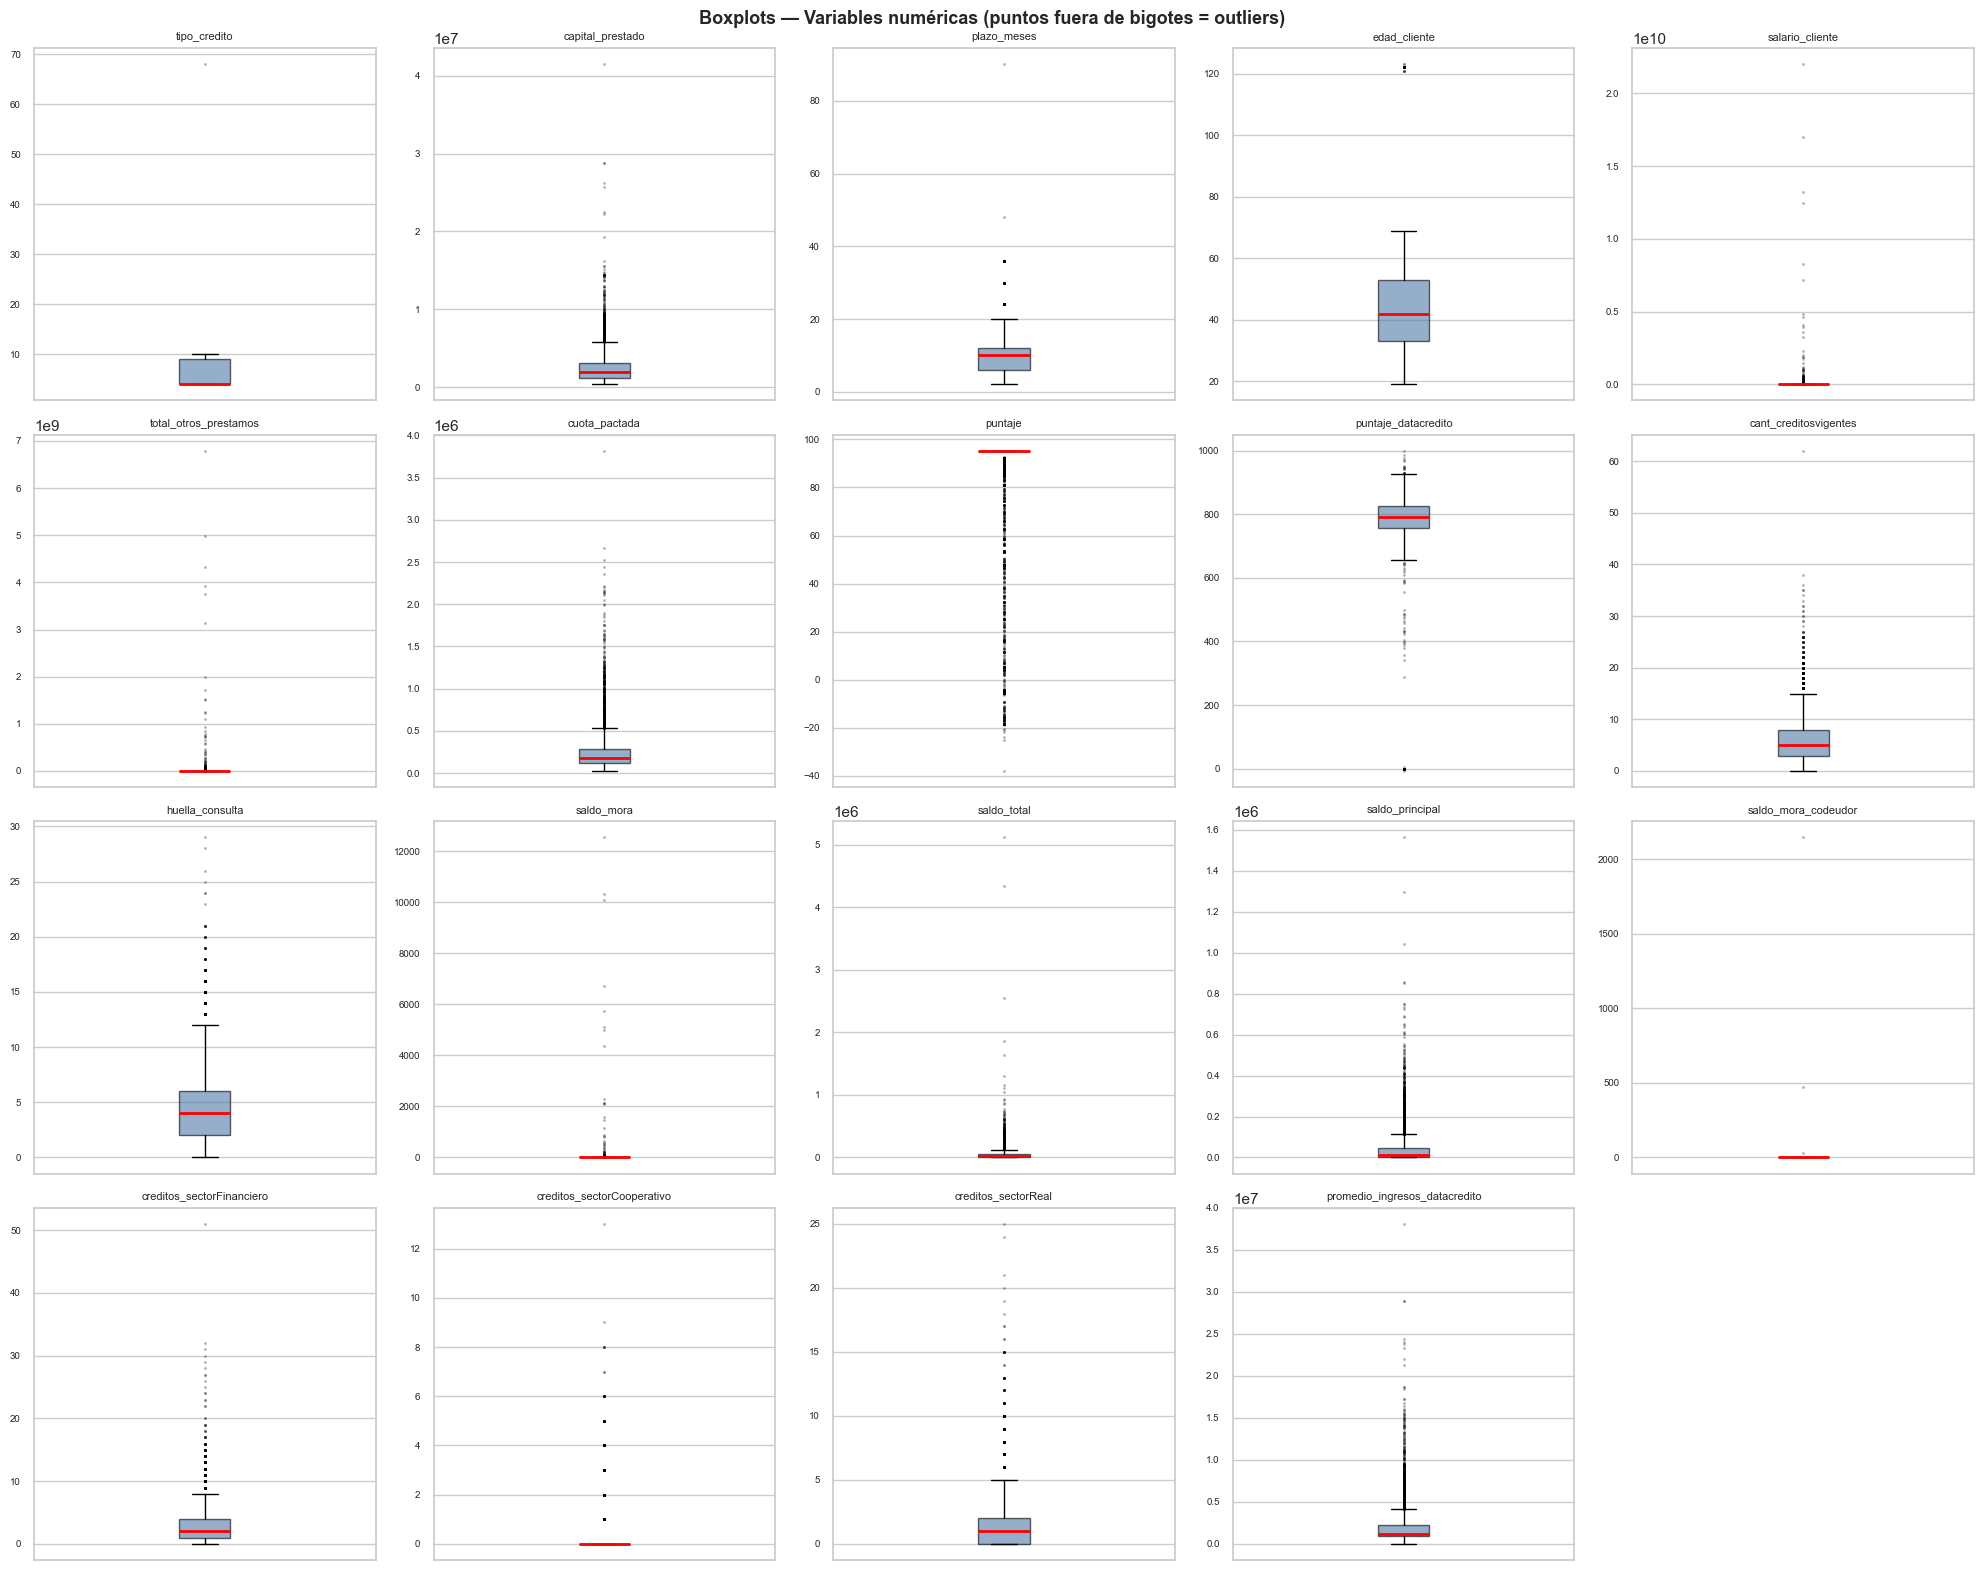

In [13]:
# =============================================================================
# Boxplots de todas las variables numéricas
# El boxplot muestra visualmente los límites IQR y los outliers como puntos
# =============================================================================

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    axes[i].boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="#4e79a7", alpha=0.6),
        medianprops=dict(color="red", linewidth=2),
        flierprops=dict(marker=".", markersize=2, alpha=0.3)  # Outliers como puntos pequeños
    )
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(axis="y", labelsize=7)
    axes[i].set_xticks([])

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots — Variables numéricas (puntos fuera de bigotes = outliers)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Cuando IQR=0 significa que Q1=Q3, es decir el 50% central de los datos tiene el mismo valor. El método IQR colapsa: los límites quedan en ese mismo valor y cualquier número diferente se clasifica como outlier. No es un outlier real, es un artefacto del método.

En creditos_sectorCooperativo el 17.6% de "outliers" son simplemente clientes que tienen al menos 1 crédito cooperativo. Eso no es anómalo, es un segmento válido de negocio.

## Lectura real de la tabla — 3 grupos

**Grupo 1 — Artefactos IQR=0 (no son outliers reales)**
- `creditos_sectorCooperativo`, `saldo_mora`, `saldo_mora_codeudor`, `puntaje`
- Decisión: ignorar el % de outliers del IQR. Tratarlos individualmente según su naturaleza.

**Grupo 2 — Outliers reales por errores de captura (acción obligatoria en Fase 3)**
- `salario_cliente` (6.67%): máximo 22 mil millones → imposible.
- `edad_cliente` (1.39%): 150 registros ≥ 83 años → límite IQR razonable para créditos.
- `puntaje_datacredito` (1.82%): 180 registros **por debajo de 655** incluyendo los negativos → imposible.
- `total_otros_prestamos` (5.47%): máximo 6.7 mil millones → error de captura.

**Grupo 3 — Outliers reales pero esperados en finanzas (decisión con criterio)**
- `capital_prestado`, `cuota_pactada`, `saldo_total`, `saldo_principal`, `promedio_ingresos_datacredito`
- Son distribuciones con cola larga natural. Los outliers existen pero son clientes reales con montos altos.
- Decisión: transformación logarítmica en Fase 3, no eliminar.


In [14]:
# =============================================================================
# Identificamos columnas donde IQR=0 (método no aplica)
# y separamos outliers reales de artefactos metodológicos
# =============================================================================

# Columnas donde el método IQR no es válido (distribución degenerada)
cols_iqr_invalido = resumen_outliers[resumen_outliers["IQR"] == 0].index.tolist()

print("=== Columnas donde IQR=0 (método no aplica) ===")
print("En estas columnas la mayoría de registros tiene el mismo valor.")
print("Los 'outliers' detectados son simplemente valores distintos a ese valor dominante.")
for col in cols_iqr_invalido:
    valor_dominante = df[col].mode()[0]
    pct_dominante = (df[col] == valor_dominante).sum() / len(df) * 100
    print(f"  {col}: valor dominante = {valor_dominante} → {pct_dominante:.1f}% de los registros")

print("\n=== Outliers reales por error de captura (acción requerida en Fase 3) ===")
casos_criticos = {
    "salario_cliente":        (df["salario_cliente"] > 1_000_000_000).sum(),
    "total_otros_prestamos":  (df["total_otros_prestamos"] > 1_000_000_000).sum(),
    "edad_cliente":           (df["edad_cliente"] >= 100).sum(),
    "puntaje_datacredito":    (df["puntaje_datacredito"] < 0).sum(),
    "puntaje":                (df["puntaje"] < 0).sum(),
}

for col, n in casos_criticos.items():
    print(f"  {col}: {n} registros con valores imposibles")

=== Columnas donde IQR=0 (método no aplica) ===
En estas columnas la mayoría de registros tiene el mismo valor.
Los 'outliers' detectados son simplemente valores distintos a ese valor dominante.
  creditos_sectorCooperativo: valor dominante = 0 → 82.4% de los registros
  puntaje: valor dominante = 95.227787 → 87.4% de los registros
  saldo_mora: valor dominante = 0.0 → 98.0% de los registros
  saldo_mora_codeudor: valor dominante = 0.0 → 94.5% de los registros

=== Outliers reales por error de captura (acción requerida en Fase 3) ===
  salario_cliente: 22 registros con valores imposibles
  total_otros_prestamos: 13 registros con valores imposibles
  edad_cliente: 150 registros con valores imposibles
  puntaje_datacredito: 1 registros con valores imposibles
  puntaje: 135 registros con valores imposibles


**Errores de captura — magnitud real:**

| Variable | Registros erróneos | % del dataset |
|---|---|---|
| `edad_cliente` | 150 | 1.39% |
| `puntaje` negativos | 135 | 1.25% |
| `salario_cliente` | 22 | 0.20% |
| `total_otros_prestamos` | 13 | 0.12% |
| `puntaje_datacredito` | 1 | 0.01% |

Ninguno supera el 1.5%. Son errores de captura puntuales, no problemas sistémicos. Se tratan en Fase 3 sin eliminar filas — solo corrigiendo los valores.

### Decisiones actualizadas para Feature Engineering

| Variable | Tipo de problema | Decisión Fase 3 |
|---|---|---|
| `salario_cliente` | Error de captura (>1.000M) | Capear en percentil 99 |
| `total_otros_prestamos` | Error de captura (>1.000M) | Capear en percentil 99 |
| `edad_cliente` | Imposible biológico (≥100) | Capear en 85 años |
| `puntaje_datacredito` | Valores negativos imposibles | Imputar negativos con mediana |
| `puntaje` | Columna degenerada (87% = 95.23, valores negativos) | Convertir a binaria `tiene_puntaje_real` |
| `capital_prestado`, `saldo_total`, `saldo_principal`, `promedio_ingresos_datacredito` | Cola larga esperada | Transformación logarítmica |
| `creditos_sectorCooperativo`, `saldo_mora`, `saldo_mora_codeudor` | IQR=0 — distribución concentrada en cero | Sin tratamiento de outliers; revisar en feature importance |
| `saldo_mora_codeudor` | 100% ceros + 5.5% nulos | Eliminar — cero varianza |

## 4. Análisis univariable — Variables categóricas

Analizamos las tres variables no numéricas del dataset.
El criterio de evaluación es: ¿las categorías tienen sentido de negocio
y frecuencia suficiente para que el modelo las aprenda?

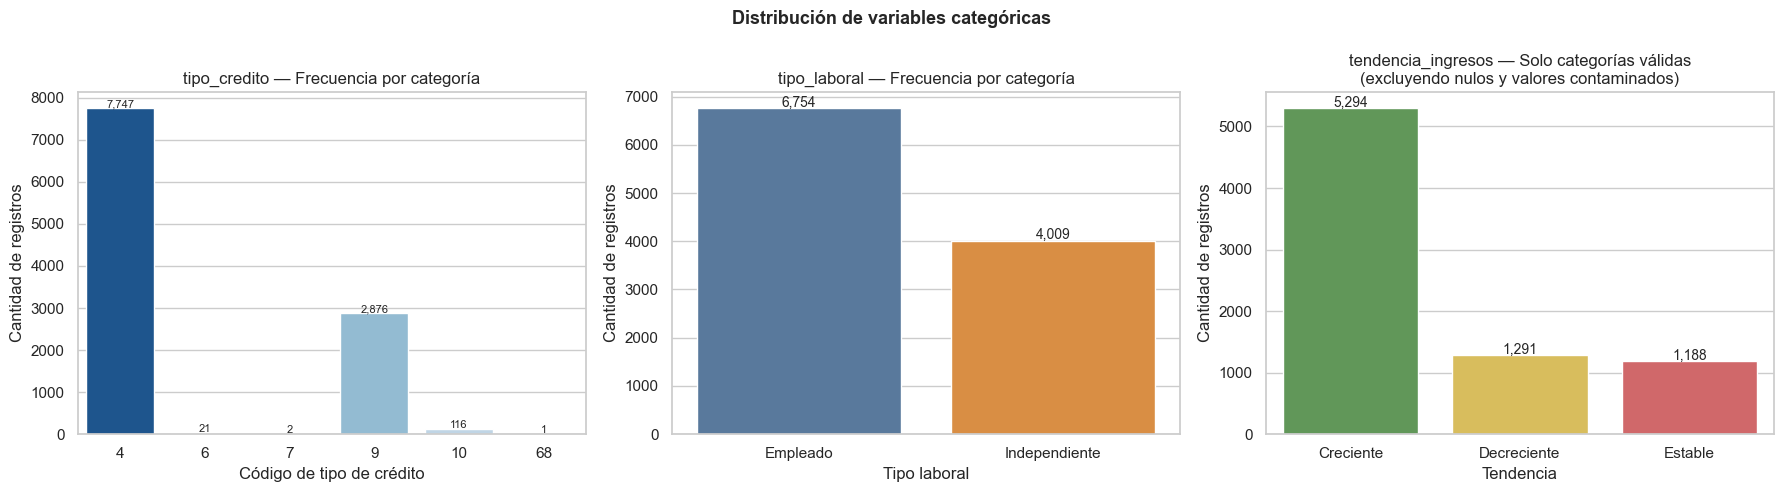

In [15]:
# =============================================================================
# Distribución de frecuencias de variables categóricas
# tipo_credito se trata como categórica aunque esté codificada como número
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- tipo_credito ---
conteo_tc = df["tipo_credito"].value_counts().sort_index()
sns.barplot(
    x=conteo_tc.index.astype(str),
    y=conteo_tc.values,
    hue=conteo_tc.index.astype(str),
    palette="Blues_r",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("tipo_credito — Frecuencia por categoría")
axes[0].set_xlabel("Código de tipo de crédito")
axes[0].set_ylabel("Cantidad de registros")
for i, v in enumerate(conteo_tc.values):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontsize=8)

# --- tipo_laboral ---
conteo_tl = df["tipo_laboral"].value_counts()
sns.barplot(
    x=conteo_tl.index,
    y=conteo_tl.values,
    hue=conteo_tl.index,
    palette=["#4e79a7", "#f28e2b"],
    legend=False,
    ax=axes[1]
)
axes[1].set_title("tipo_laboral — Frecuencia por categoría")
axes[1].set_xlabel("Tipo laboral")
axes[1].set_ylabel("Cantidad de registros")
for i, v in enumerate(conteo_tl.values):
    axes[1].text(i, v + 30, f"{v:,}", ha="center", fontsize=10)

# --- tendencia_ingresos: solo categorías válidas ---
categorias_validas = ["Creciente", "Estable", "Decreciente"]
conteo_ti = df[df["tendencia_ingresos"].isin(categorias_validas)]["tendencia_ingresos"].value_counts()
sns.barplot(
    x=conteo_ti.index,
    y=conteo_ti.values,
    hue=conteo_ti.index,
    palette=["#59a14f", "#edc948", "#e15759"],
    legend=False,
    ax=axes[2]
)
axes[2].set_title("tendencia_ingresos — Solo categorías válidas\n(excluyendo nulos y valores contaminados)")
axes[2].set_xlabel("Tendencia")
axes[2].set_ylabel("Cantidad de registros")
for i, v in enumerate(conteo_ti.values):
    axes[2].text(i, v + 20, f"{v:,}", ha="center", fontsize=10)

plt.suptitle("Distribución de variables categóricas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [16]:
# =============================================================================
# Diagnóstico de contaminación en tendencia_ingresos
# La columna mezcla categorías texto con valores numéricos sueltos
# Estos valores numéricos son errores de captura — probablemente valores
# de ingresos que se ingresaron en la columna equivocada
# =============================================================================

categorias_validas = ["Creciente", "Estable", "Decreciente"]

# Registros con valor no nulo pero tampoco categórico válido
mask_contaminados = (
    df["tendencia_ingresos"].notna() &
    ~df["tendencia_ingresos"].isin(categorias_validas)
)

n_contaminados = mask_contaminados.sum()
print(f"Registros con valor inválido en tendencia_ingresos: {n_contaminados}")
print(f"Porcentaje sobre total: {n_contaminados / len(df) * 100:.2f}%")
print(f"\nValores inválidos encontrados:")
print(df[mask_contaminados]["tendencia_ingresos"].value_counts())

Registros con valor inválido en tendencia_ingresos: 58
Porcentaje sobre total: 0.54%

Valores inválidos encontrados:
tendencia_ingresos
0          7
8315       6
1000000    4
9147       2
158042     1
3978       1
168750     1
-28589     1
-566272    1
24702      1
31837      1
122727     1
417087     1
9090       1
173031     1
-70715     1
-435177    1
-702927    1
-4105      1
54683      1
22832      1
209090     1
5697       1
10808      1
-288       1
-164315    1
2029000    1
17181      1
15245      1
82657      1
52862      1
1817052    1
75761      1
146918     1
1123000    1
15090      1
4250635    1
22363      1
-101368    1
86286      1
65988      1
77975      1
-224714    1
Name: count, dtype: int64


## 5. Análisis bivariable — Features vs Pago_atiempo

Para cada variable analizamos si su distribución difiere entre clientes
que pagan (clase 1) y clientes que no pagan (clase 0).

Si una variable **no muestra diferencia entre clases**, probablemente
no aporte señal útil al modelo.

Si **sí muestra diferencia**, es candidata a feature importante.

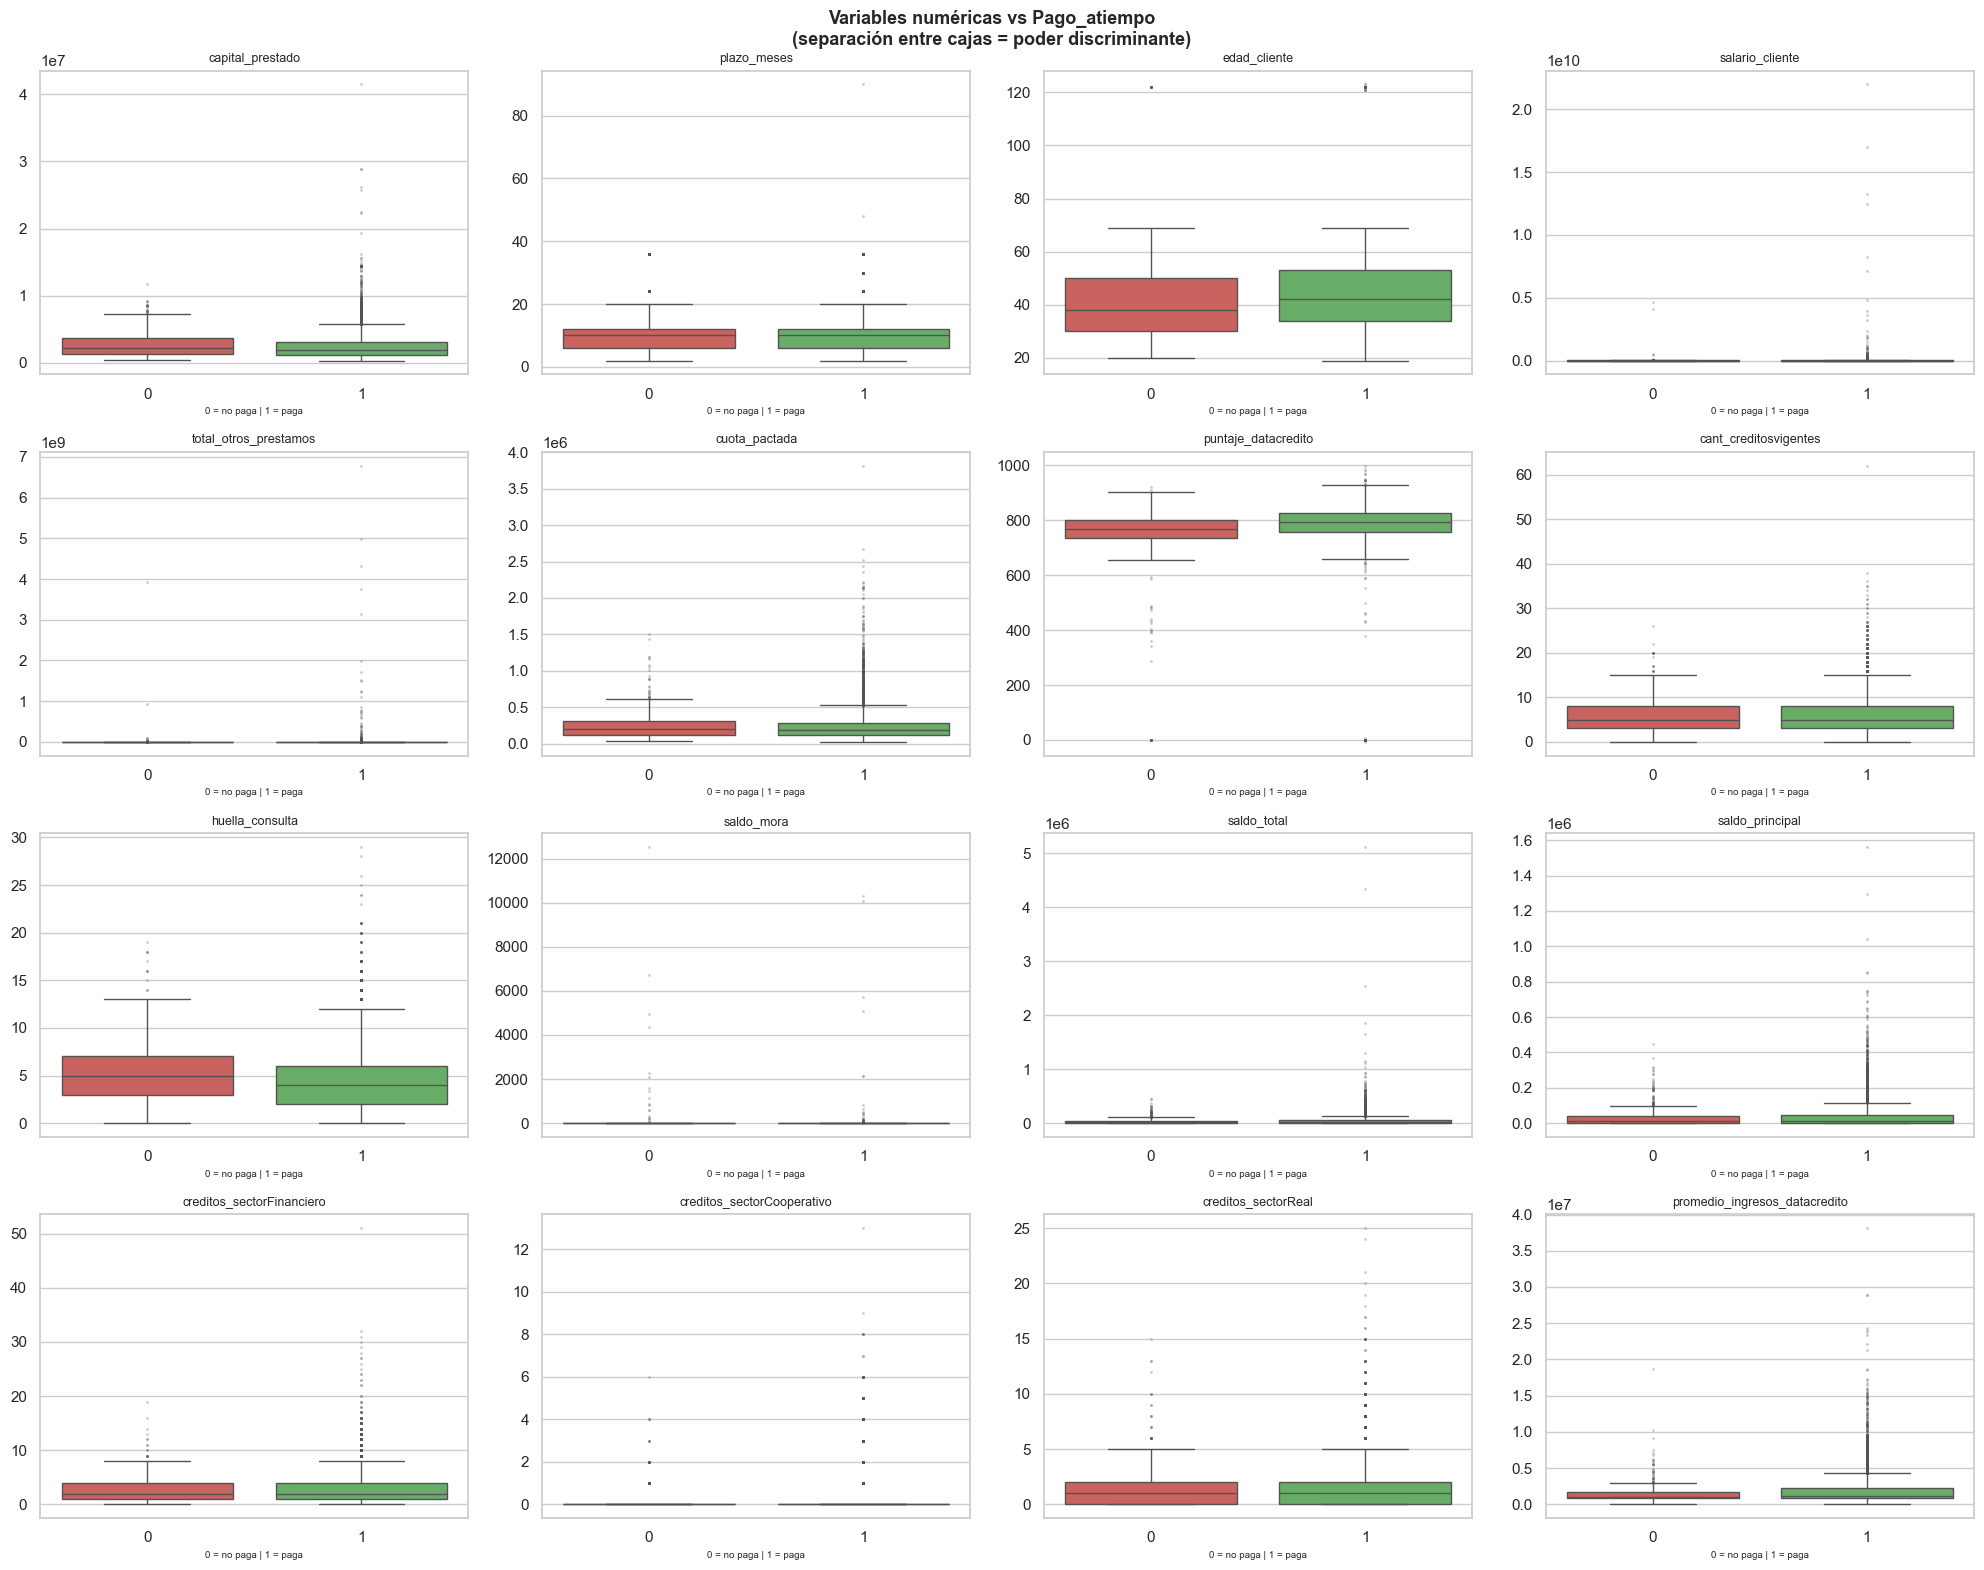

In [17]:
# =============================================================================
# Bivariable: variables numéricas vs Pago_atiempo
# Boxplot por clase: si las cajas se separan, la variable discrimina
# Paleta: rojo = no paga (0), verde = paga (1)
# =============================================================================

# Variables a graficar (excluimos las degeneradas con IQR=0 para mejor legibilidad)
cols_bivariable = [
    "capital_prestado", "plazo_meses", "edad_cliente",
    "salario_cliente", "total_otros_prestamos", "cuota_pactada",
    "puntaje_datacredito", "cant_creditosvigentes", "huella_consulta",
    "saldo_mora", "saldo_total", "saldo_principal",
    "creditos_sectorFinanciero", "creditos_sectorCooperativo",
    "creditos_sectorReal", "promedio_ingresos_datacredito"
]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cols_bivariable):
    sns.boxplot(
        data=df,
        x="Pago_atiempo",
        y=col,
        hue="Pago_atiempo",
        palette={0: "#d9534f", 1: "#5cb85c"},
        legend=False,
        flierprops=dict(marker=".", markersize=2, alpha=0.3),
        ax=axes[i]
    )
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("0 = no paga | 1 = paga", fontsize=7)
    axes[i].set_ylabel("")

plt.suptitle("Variables numéricas vs Pago_atiempo\n(separación entre cajas = poder discriminante)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

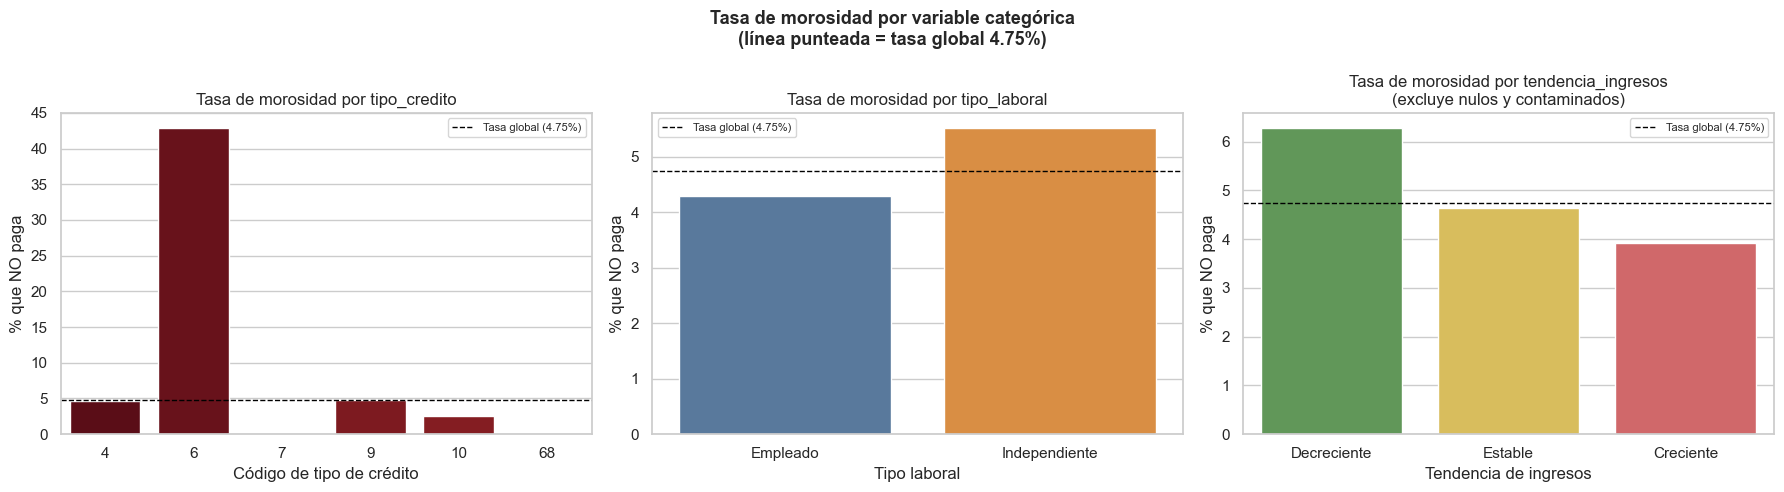

In [18]:
# =============================================================================
# Bivariable: variables categóricas vs Pago_atiempo
# Mostramos la TASA DE MOROSIDAD (% que NO paga) por categoría
# Un countplot crudo no sirve porque el desbalance distorsiona la lectura
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- tipo_credito ---
tasa_tc = (df.groupby("tipo_credito")["Pago_atiempo"]
             .apply(lambda x: (x == 0).sum() / len(x) * 100)
             .reset_index())
tasa_tc.columns = ["tipo_credito", "tasa_morosidad"]
tasa_tc = tasa_tc.sort_values("tasa_morosidad", ascending=False)

sns.barplot(
    data=tasa_tc,
    x="tipo_credito",
    y="tasa_morosidad",
    hue="tipo_credito",
    palette="Reds_r",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Tasa de morosidad por tipo_credito")
axes[0].set_xlabel("Código de tipo de crédito")
axes[0].set_ylabel("% que NO paga")
axes[0].axhline(y=4.75, color="black", linestyle="--",
                linewidth=1, label="Tasa global (4.75%)")
axes[0].legend(fontsize=8)

# --- tipo_laboral ---
tasa_tl = (df.groupby("tipo_laboral")["Pago_atiempo"]
             .apply(lambda x: (x == 0).sum() / len(x) * 100)
             .reset_index())
tasa_tl.columns = ["tipo_laboral", "tasa_morosidad"]

sns.barplot(
    data=tasa_tl,
    x="tipo_laboral",
    y="tasa_morosidad",
    hue="tipo_laboral",
    palette=["#4e79a7", "#f28e2b"],
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Tasa de morosidad por tipo_laboral")
axes[1].set_xlabel("Tipo laboral")
axes[1].set_ylabel("% que NO paga")
axes[1].axhline(y=4.75, color="black", linestyle="--", linewidth=1,
                label="Tasa global (4.75%)")
axes[1].legend(fontsize=8)

# --- tendencia_ingresos (solo válidas) ---
categorias_validas = ["Creciente", "Estable", "Decreciente"]
df_tend = df[df["tendencia_ingresos"].isin(categorias_validas)]
tasa_ti = (df_tend.groupby("tendencia_ingresos")["Pago_atiempo"]
                  .apply(lambda x: (x == 0).sum() / len(x) * 100)
                  .reset_index())
tasa_ti.columns = ["tendencia_ingresos", "tasa_morosidad"]
tasa_ti = tasa_ti.sort_values("tasa_morosidad", ascending=False)

sns.barplot(
    data=tasa_ti,
    x="tendencia_ingresos",
    y="tasa_morosidad",
    hue="tendencia_ingresos",
    palette=["#59a14f", "#edc948", "#e15759"],
    legend=False,
    ax=axes[2]
)
axes[2].set_title("Tasa de morosidad por tendencia_ingresos\n(excluye nulos y contaminados)")
axes[2].set_xlabel("Tendencia de ingresos")
axes[2].set_ylabel("% que NO paga")
axes[2].axhline(y=4.75, color="black", linestyle="--", linewidth=1,
                label="Tasa global (4.75%)")
axes[2].legend(fontsize=8)

plt.suptitle("Tasa de morosidad por variable categórica\n(línea punteada = tasa global 4.75%)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

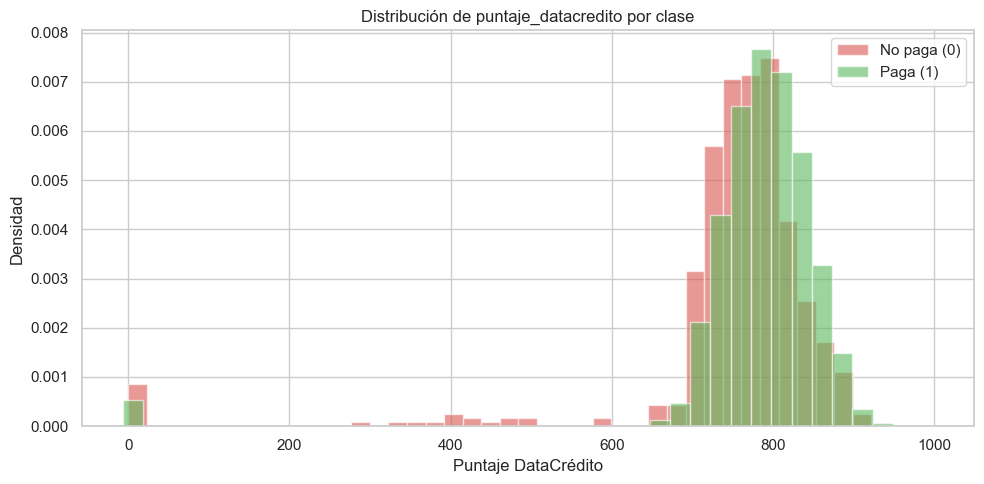

=== puntaje_datacredito por clase ===
               mean  median    std
Pago_atiempo                      
0            748.90  768.00 130.90
1            782.40  792.00 103.20


In [19]:
# =============================================================================
# puntaje_datacredito vs Pago_atiempo — histograma superpuesto
# Es la variable con mayor intuición de negocio: score crediticio
# Si discrimina, debería verse claramente separado entre clases
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))

# Histograma clase 0 (no paga)
ax.hist(
    df[df["Pago_atiempo"] == 0]["puntaje_datacredito"].dropna(),
    bins=40, alpha=0.6, color="#d9534f", label="No paga (0)", density=True
)

# Histograma clase 1 (paga)
ax.hist(
    df[df["Pago_atiempo"] == 1]["puntaje_datacredito"].dropna(),
    bins=40, alpha=0.6, color="#5cb85c", label="Paga (1)", density=True
)

ax.set_title("Distribución de puntaje_datacredito por clase", fontsize=12)
ax.set_xlabel("Puntaje DataCrédito")
ax.set_ylabel("Densidad")
ax.legend()
plt.tight_layout()
plt.show()

# Estadísticos por clase
print("=== puntaje_datacredito por clase ===")
print(df.groupby("Pago_atiempo")["puntaje_datacredito"]
        .agg(["mean", "median", "std"])
        .round(1))

### Ranking preliminar de variables por poder discriminante

| Prioridad | Variable | Señal |
|---|---|---|
| Alta | `puntaje_datacredito` | Separación + dispersión diferencial |
| Alta | `edad_cliente` | Morosos más jóvenes |
| Alta | `tipo_credito` (códigos 4 y 9) | Tasas distintas con base estadística |
| Media | `huella_consulta` | Morosos con más consultas al buró |
| Media | `tendencia_ingresos` | Decreciente mora más que Creciente |
| Media | `tipo_laboral` | Independiente mora más que Empleado |
| Baja | `capital_prestado`, `plazo_meses`, `cuota_pactada` | Sin separación visible |
| Baja | Variables de saldo | Dominadas por outliers, difícil leer |


## 6. Análisis multivariable — Correlaciones y redundancias

Verificamos relaciones entre variables para detectar multicolinealidad.
Variables altamente correlacionadas entre sí aportan información redundante
al modelo y pueden inflar artificialmente la importancia de algunas features.

Hipótesis a confirmar:
1. `cuota_pactada` es casi derivable de `capital_prestado` y `plazo_meses`
2. `saldo_total` y `saldo_principal` están fuertemente correlacionados
3. Los tres sectores de crédito correlacionan con `cant_creditosvigentes`

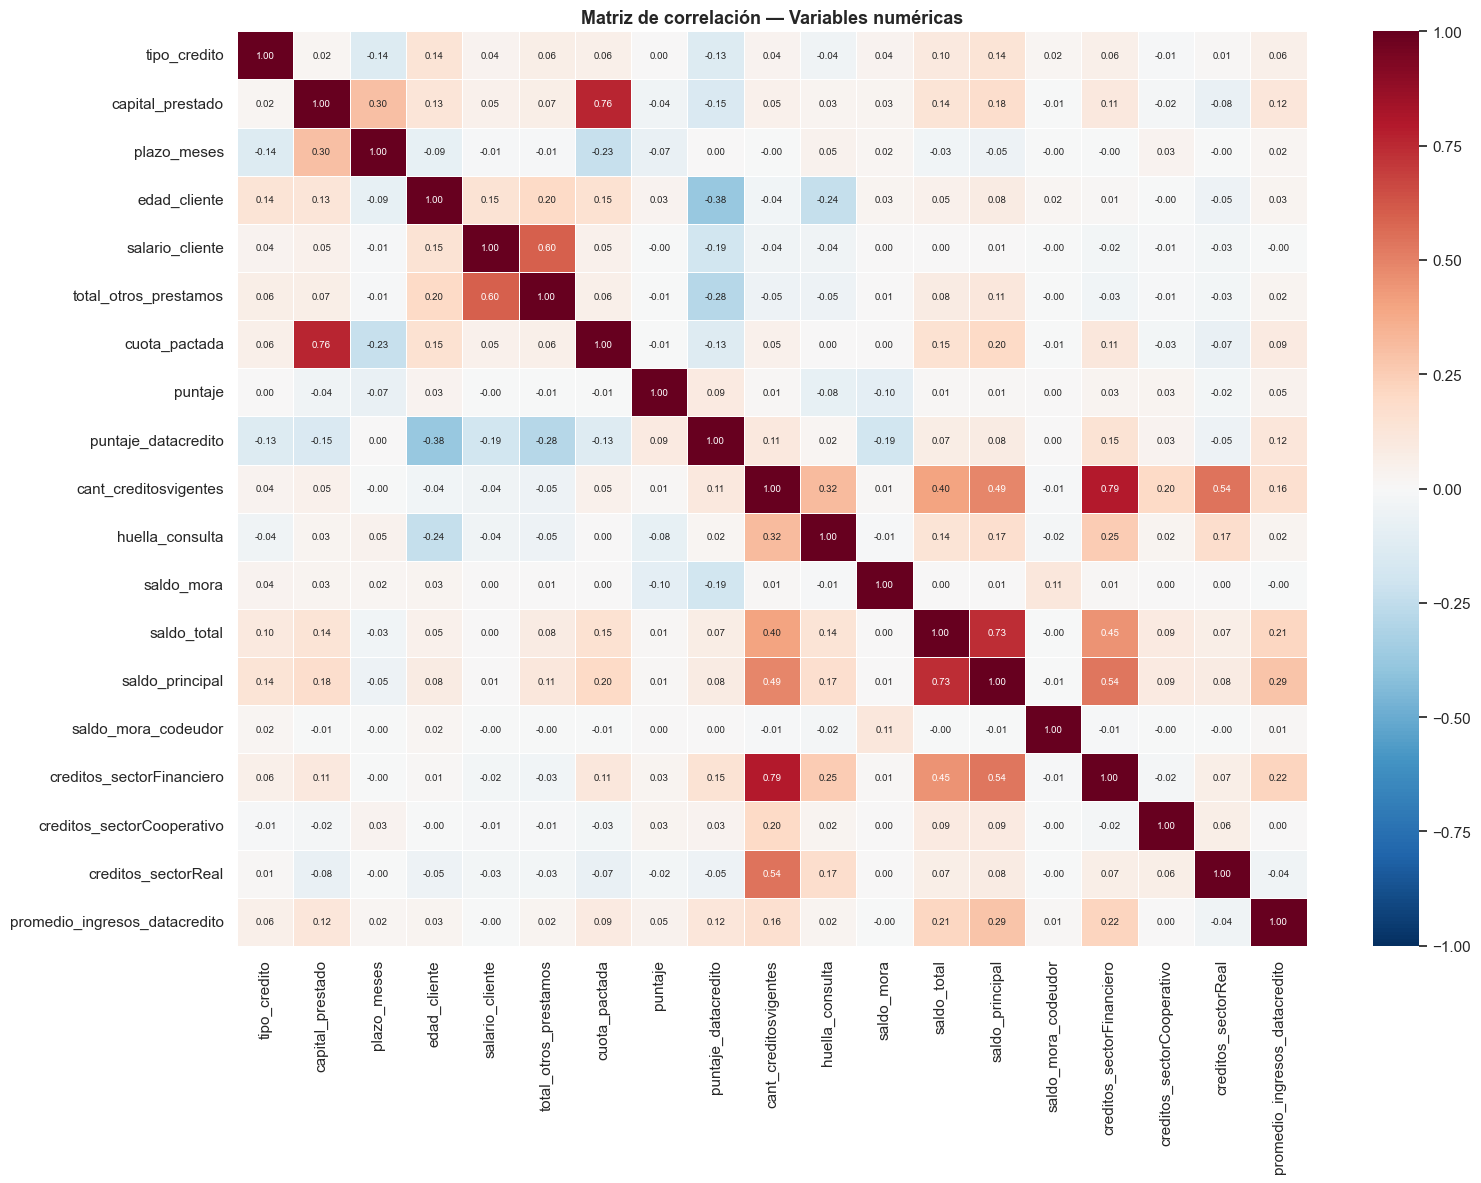

=== Pares con correlación alta (|r| > 0.70) ===


In [20]:
# =============================================================================
# Matriz de correlación de Pearson — variables numéricas
# Pearson mide relación lineal entre -1 y 1
# Valores cercanos a 1 o -1 indican redundancia potencial
# Excluimos el target para ver solo relaciones entre features
# =============================================================================

# Seleccionamos numéricas sin el target
cols_corr = [c for c in cols_numericas if c != "Pago_atiempo"]

# Calculamos matriz de correlación
corr_matrix = df[cols_corr].corr()

# Graficamos heatmap
fig, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,           # Muestra el valor numérico en cada celda
    fmt=".2f",            # Dos decimales
    cmap="RdBu_r",        # Rojo = correlación positiva, azul = negativa
    center=0,             # Blanco en 0 (sin correlación)
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 7},
    ax=ax
)

ax.set_title("Matriz de correlación — Variables numéricas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Identificamos pares con correlación alta (> 0.7 o < -0.7), excluyendo diagonal
print("=== Pares con correlación alta (|r| > 0.70) ===")
umbral = 0.70
pares_altos = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):  # Solo triángulo superior
        r = corr_matrix.iloc[i, j]
        if abs(r) > umbral:
            pares_altos.append({
                "variable_1": corr_matrix.columns[i],
                "variable_2": corr_matrix.columns[j],
                "correlacion": round(r, 3)
            })

if pares_altos:
    pd.DataFrame(pares_altos).sort_values("correlacion", ascending=False)
else:
    print("Ningún par supera el umbral de 0.70")

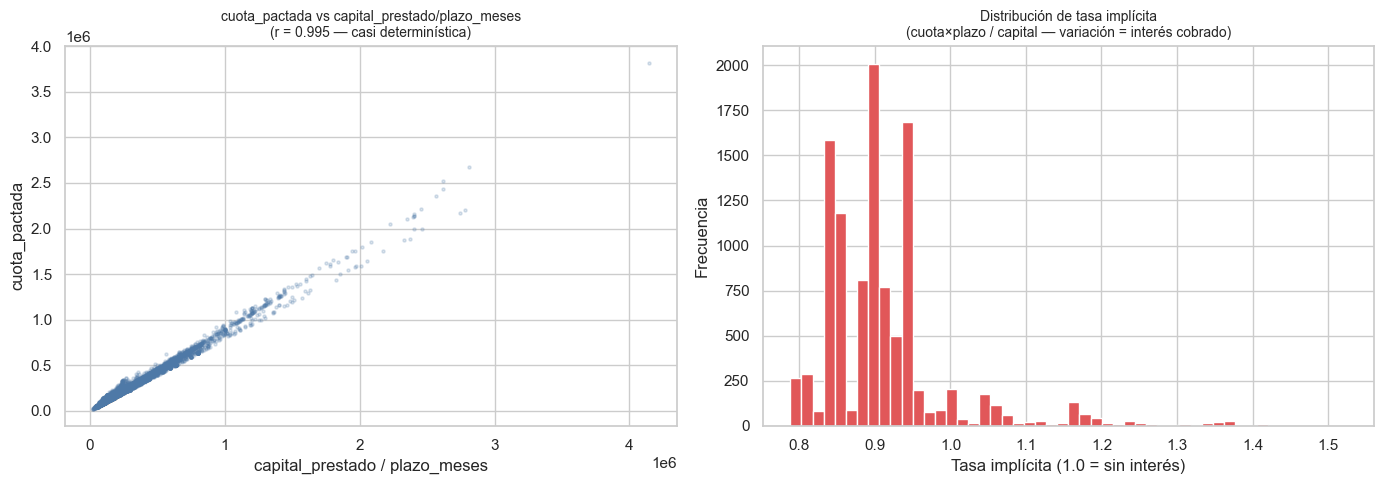

Tasa implícita — estadísticos:
count   10,763.00
mean         0.91
std          0.09
min          0.79
25%          0.85
50%          0.89
75%          0.94
max          1.52
Name: _tasa_implicita, dtype: float64

Correlación tasa_implicita vs Pago_atiempo: -0.039


In [21]:
# =============================================================================
# Verificación de la redundancia cuota_pactada vs capital/plazo
# Si la correlación es ~0.995, cuota_pactada no aporta información nueva
# por sí sola — la diferencia residual es la tasa de interés implícita
# =============================================================================

# Creamos el ratio capital/plazo como aproximación sin interés
df["_ratio_capital_plazo"] = df["capital_prestado"] / df["plazo_meses"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scatter: cuota_pactada vs ratio capital/plazo ---
axes[0].scatter(
    df["_ratio_capital_plazo"],
    df["cuota_pactada"],
    alpha=0.2,
    s=5,
    color="#4e79a7"
)
axes[0].set_title("cuota_pactada vs capital_prestado/plazo_meses\n(r = 0.995 — casi determinística)",
                  fontsize=10)
axes[0].set_xlabel("capital_prestado / plazo_meses")
axes[0].set_ylabel("cuota_pactada")

# --- La diferencia residual: tasa implícita ---
# Si cuota = capital/plazo exacto → tasa implicita = 1.0 (sin interés)
# Cuanto mayor el ratio, más caro le prestaron al cliente
df["_tasa_implicita"] = (df["cuota_pactada"] * df["plazo_meses"]) / df["capital_prestado"]

axes[1].hist(
    df["_tasa_implicita"].dropna(),
    bins=50,
    color="#e15759",
    edgecolor="white"
)
axes[1].set_title("Distribución de tasa implícita\n(cuota×plazo / capital — variación = interés cobrado)",
                  fontsize=10)
axes[1].set_xlabel("Tasa implícita (1.0 = sin interés)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# Limpiamos columnas temporales del análisis
df.drop(columns=["_ratio_capital_plazo"], inplace=True)

# Renombramos _tasa_implicita para documentar que es candidata a feature
print(f"Tasa implícita — estadísticos:")
print(df["_tasa_implicita"].describe().round(3))
print(f"\nCorrelación tasa_implicita vs Pago_atiempo: "
      f"{df['_tasa_implicita'].corr(df['Pago_atiempo']):.3f}")

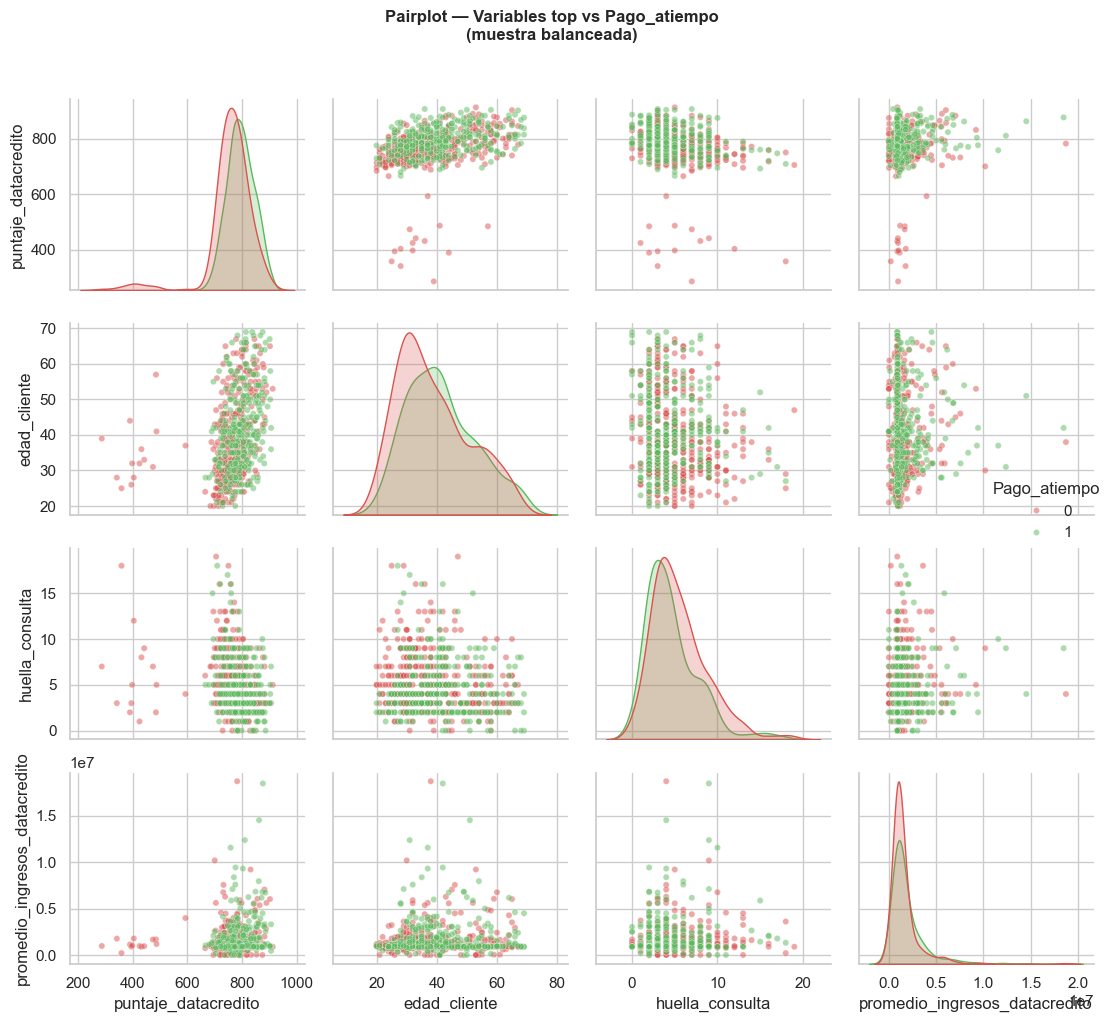

In [22]:
# =============================================================================
# Pairplot de las variables con mayor poder discriminante identificadas en S5
# Coloreado por target para ver separación conjunta entre clases
# Usamos muestra para no saturar el gráfico (10k puntos es demasiado)
# =============================================================================

cols_top = [
    "puntaje_datacredito",
    "edad_cliente",
    "huella_consulta",
    "promedio_ingresos_datacredito",
    "Pago_atiempo"
]

# Muestra estratificada: 300 de clase 0 (todos) + 300 de clase 1
df_muestra = pd.concat([
    df[df["Pago_atiempo"] == 0].dropna(subset=cols_top),        # Todos los morosos
    df[df["Pago_atiempo"] == 1].dropna(subset=cols_top).sample(300, random_state=42)
])

sns.pairplot(
    df_muestra[cols_top],
    hue="Pago_atiempo",
    palette={0: "#d9534f", 1: "#5cb85c"},
    plot_kws={"alpha": 0.5, "s": 20},
    diag_kind="kde"         # Curva de densidad en la diagonal
)

plt.suptitle("Pairplot — Variables top vs Pago_atiempo\n(muestra balanceada)",
             y=1.02, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### Conclusiones del análisis multivariable

#### Correlaciones altas confirmadas
| Par | Correlación | Decisión Fase 3 |
|---|---|---|
| `cuota_pactada` ↔ `capital_prestado/plazo_meses` | ~0.995 | Eliminar `cuota_pactada`; crear `tasa_implicita` como feature derivada |
| `saldo_total` ↔ `saldo_principal` | ~0.73 | Mantener ambas por ahora; revisar en feature importance |

#### Señal de la tasa implícita
La diferencia entre `cuota_pactada` y el ratio `capital/plazo` captura
la tasa de interés que el banco le cobró a cada cliente — una señal
directa de cuánto riesgo le asignó el banco al momento del préstamo.
Esta feature derivada se crea en `ft_engineering.py`.

#### Variables independientes entre sí (sin multicolinealidad)
`puntaje_datacredito`, `edad_cliente`, `huella_consulta` y
`promedio_ingresos_datacredito` no correlacionan fuertemente entre sí.
Son candidatas a entrar juntas al modelo sin generar redundancia.

## 7. Conclusiones del EDA y decisiones para Feature Engineering

Este notebook diagnosticó el dataset `Base_de_datos.csv` (10.763 registros,
23 columnas) con foco en el problema de negocio: predecir si un cliente
pagará su crédito a tiempo (`Pago_atiempo`).

Todas las decisiones documentadas aquí se **ejecutan en `ft_engineering.py`**.
Este notebook no modifica el dataset original.

---

### 7.1 Hallazgos críticos del dataset

#### Desbalance del target
La variable objetivo presenta un desbalance severo:
- **95.3% paga a tiempo** (clase 1): 10.252 registros
- **4.7% no paga** (clase 0): 511 registros

Esto invalida el uso de `accuracy` como métrica. El modelo debe optimizarse
con **ROC-AUC** y **F1-score de la clase 0** (morosos). El split de datos
debe usar `stratify=y` para preservar la proporción en train y test.

#### Calidad de los datos
| Tipo de problema | Variables afectadas | Magnitud |
|---|---|---|
| Nulos altos (27%) | `promedio_ingresos_datacredito`, `tendencia_ingresos` | 2.930 / 2.932 registros |
| Nulos bajos (<6%) | `saldo_mora_codeudor`, `saldo_principal`, `saldo_mora`, `saldo_total`, `puntaje_datacredito` | 6 a 590 registros |
| Valores imposibles | `edad_cliente` (≥100), `salario_cliente` (>1.000M), `puntaje` y `puntaje_datacredito` (negativos) | 22 a 150 registros |
| Contaminación de columna | `tendencia_ingresos` contiene valores numéricos sueltos | 58 registros (0.54%) |
| Columna degenerada | `puntaje`: 87.4% de registros con valor exacto 95.227787 | 9.407 registros |
| Cero varianza | `saldo_mora_codeudor`: 100% de no-nulos son cero | Columna inútil |
| Redundancia casi perfecta | `cuota_pactada` ≈ `capital_prestado / plazo_meses` (r=0.995) | Columna derivable |

---

### 7.2 Variables con mayor poder discriminante

Ranking basado en el análisis bivariable (Sección 5):

| Prioridad | Variable | Evidencia |
|---|---|---|
| 🔴 Alta | `puntaje_datacredito` | Media morosos: 748 vs pagadores: 782. Cola izquierda exclusiva de morosos |
| 🔴 Alta | `edad_cliente` | Morosos son sistemáticamente más jóvenes |
| 🔴 Alta | `tipo_credito` | Código 6 mora 42% (pocos casos); códigos 4 y 9 muestran diferencia válida |
| 🟡 Media | `huella_consulta` | Morosos tienen más consultas al buró — señal de búsqueda de liquidez |
| 🟡 Media | `tendencia_ingresos` | Decreciente mora 6.2% vs Creciente mora 3.9% |
| 🟡 Media | `tipo_laboral` | Independiente mora más que Empleado (5.2% vs 4.3%) |
| 🟡 Media | `tasa_implicita` (derivada) | Captura el riesgo percibido por el banco al pactar el crédito |
| 🟢 Baja | `capital_prestado`, `plazo_meses`, `cuota_pactada` | Sin separación visible entre clases |
| 🟢 Baja | Variables de saldo | Dominadas por outliers; difícil leer señal sin transformación |

---

### 7.3 Decisiones para `ft_engineering.py`

#### Columnas a eliminar
| Columna | Motivo |
|---|---|
| `saldo_mora_codeudor` | 100% de no-nulos son cero. Cero varianza, no aporta señal |
| `cuota_pactada` | Redundante con `capital_prestado / plazo_meses` (r=0.995) |
| `puntaje` | 87.4% con valor placeholder. Se reemplaza por feature derivada binaria |

#### Features derivadas a crear
| Feature nueva | Fórmula | Justificación |
|---|---|---|
| `tasa_implicita` | `(cuota_pactada × plazo_meses) / capital_prestado` | Captura tasa de interés cobrada al cliente — señal de riesgo percibido por el banco |
| `tiene_datacredito` | `1 si promedio_ingresos_datacredito no es nulo, 0 si nulo` | No tener historial en DataCrédito es en sí mismo una señal de riesgo |
| `tiene_puntaje_real` | `0 si puntaje == 95.227787, 1 en caso contrario` | Distingue clientes con score real de los que tienen valor placeholder |

#### Tratamiento de outliers y valores imposibles
| Variable | Problema | Acción |
|---|---|---|
| `salario_cliente` | Valores > 1.000 millones | Capear en percentil 99 |
| `total_otros_prestamos` | Valores > 1.000 millones | Capear en percentil 99 |
| `edad_cliente` | Valores ≥ 100 años | Capear en 85 años |
| `puntaje_datacredito` | Valores negativos | Imputar con mediana |
| `tendencia_ingresos` | 58 valores numéricos contaminados | Convertir a NaN |

#### Imputación de nulos
| Variable | % Nulos | Estrategia |
|---|---|---|
| `promedio_ingresos_datacredito` | 27% | Crear `tiene_datacredito` primero; luego imputar con mediana |
| `tendencia_ingresos` | 27% | Normalizar contaminados a NaN; imputar con categoría `"Sin_info"` |
| `saldo_mora_codeudor` | 5.5% | **Eliminar columna** (cero varianza) |
| `saldo_principal` | 3.7% | Imputar con mediana |
| `saldo_mora` | 1.45% | Imputar con 0 (créditos nuevos sin historial) |
| `saldo_total` | 1.45% | Imputar con 0 (mismos 156 registros que `saldo_mora`) |
| `puntaje_datacredito` | 0.06% | Imputar con mediana |

#### Encoding de categóricas
| Variable | Estrategia |
|---|---|
| `tipo_laboral` | Encoding binario (Empleado=0, Independiente=1) |
| `tendencia_ingresos` | OneHotEncoding de 3 categorías + `"Sin_info"` |
| `tipo_credito` | Agrupar códigos 6, 7, 68 en `"otro"`; luego OneHotEncoding |

#### Transformaciones de escala
| Variables | Transformación | Motivo |
|---|---|---|
| `capital_prestado`, `salario_cliente`, `total_otros_prestamos`, `saldo_total`, `saldo_principal`, `promedio_ingresos_datacredito` | Log(x + 1) | Sesgo positivo marcado; la transformación logarítmica normaliza la distribución |

---

### 7.4 Hipótesis para el modelo

Basado en el EDA, se espera que el modelo final identifique como
principales predictores de morosidad:

1. **Score crediticio bajo** (`puntaje_datacredito` < 750)
2. **Cliente joven** (`edad_cliente` < 30)
3. **Trabajador independiente** con **ingresos decrecientes**
4. **Alta huella de consultas** al buró en período reciente
5. **Sin historial en DataCrédito** (`tiene_datacredito` = 0)
6. **Tasa implícita alta** — el banco ya lo percibía como riesgoso al otorgar el crédito

Estas hipótesis se verifican o refutan en `model_training_evaluation.py`
mediante el análisis de feature importance del modelo seleccionado.